In [118]:
import boto3
from botocore.exceptions import ClientError
import json

def get_secret(secret_name):
    region_name = "us-east-1"

    # Create a Secrets Manager client
    session = boto3.session.Session()
    client = session.client(
        service_name='secretsmanager',
        region_name=region_name
    )

    try:
        get_secret_value_response = client.get_secret_value(
            SecretId=secret_name
        )
    except ClientError as e:
        raise e

    secret = get_secret_value_response['SecretString']
    
    return json.loads(secret)

In [ ]:
import psycopg2

conn = psycopg2.connect(host=get_secret('postgresql')['host'],
                      user=get_secret('postgresql')['username'],
                      password = get_secret('postgresql')['password'],
                      dbname=get_secret('postgresql')['engine'])

cur = conn.cursor()

## Q1 - Population Growth Rate

option A: do the calculation with SQL

In [107]:
sql = """
     select * from name_income
     where fips = '51'
     """

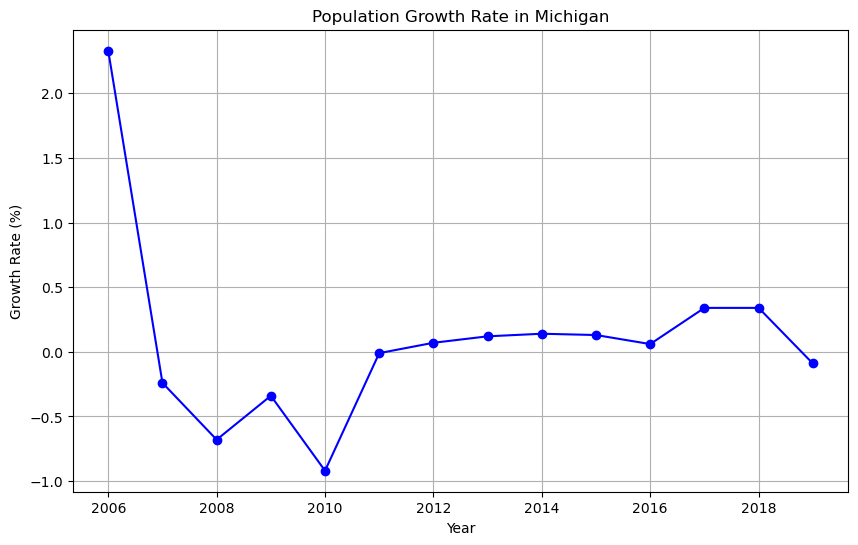

In [106]:
import pandas as pd
import matplotlib.pyplot as plt

query = """
SELECT p.year,
       p.pop,
       ROUND(100.0 * (p.pop - LAG(p.pop) OVER (ORDER BY p.year)) / LAG(p.pop) OVER (ORDER BY p.year), 2) 
       AS growth_rate
FROM population p
JOIN name n ON p.fips = n.fips
WHERE n.name = 'Michigan'
ORDER BY p.year;
"""

df = pd.read_sql(query, conn)

plt.figure(figsize=(10,6))
plt.plot(df['year'], df['growth_rate'], marker='o', color="blue")
plt.title("Population Growth Rate in Michigan")
plt.xlabel("Year")
plt.ylabel("Growth Rate (%)")
plt.grid(True)
plt.show()

Q1: The graph shows that Michigan’s population has experienced periods of both growth and decline. 
The growth rate tends to fluctuate slightly, showing slow population increases in earlier years 
and smaller or even negative changes in more recent years.This indicates that Michigan’s population
growth has stabilized over time, likely due to factors like lower birth rates and migration to other states.

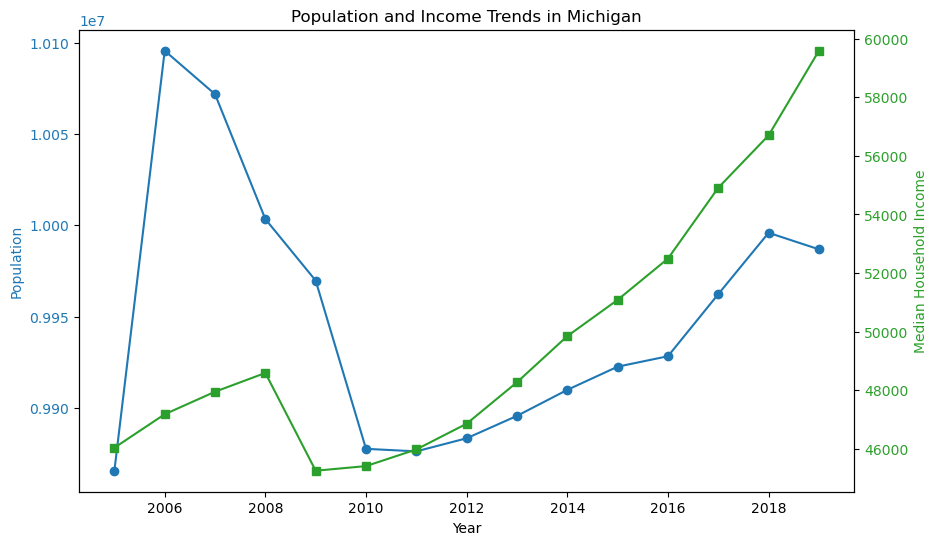

In [110]:
query = """
SELECT i.year, i.income, p.pop
FROM income i
JOIN population p 
  ON i.fips = p.fips AND i.year = p.year
JOIN name n 
  ON i.fips = n.fips
WHERE n.name = 'Michigan'
ORDER BY i.year;
"""

df = pd.read_sql(query, conn)

fig, ax1 = plt.subplots(figsize=(10,6))

ax1.set_xlabel("Year")
ax1.set_ylabel("Population", color="tab:blue")
ax1.plot(df['year'], df['pop'], color="tab:blue", marker="o")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.set_ylabel("Median Household Income", color="tab:green")
ax2.plot(df['year'], df['income'], color="tab:green", marker="s")
ax2.tick_params(axis="y", labelcolor="tab:green")

plt.title("Population and Income Trends in Michigan")
plt.show()

Q2: Both population and median household income have changed notably over time in Michigan. 
The population line remains stable, while income shows a more consistent increase.  
This suggests that while the state’s population growth has slowed, its economic conditions 
and wages have improved. The steady rise in income could reflect economic recovery, 
especially following periods of industrial change in Michigan’s economy. Overall, the 
state shows positive financial growth despite limited population increases.

In [114]:
query = """
SELECT 
    year,
    income,
    income - LAG(income) OVER (ORDER BY year) AS income_change
FROM income i
JOIN name n ON i.fips = n.fips
WHERE n.name = 'Michigan'
ORDER BY year;
"""

df = pd.read_sql(query, conn)

# Filter only years where income dropped
decline_df = df[df['income_change'] < 0]
display(decline_df)

,year,income,income_change
4,2009,45255,-3336.0


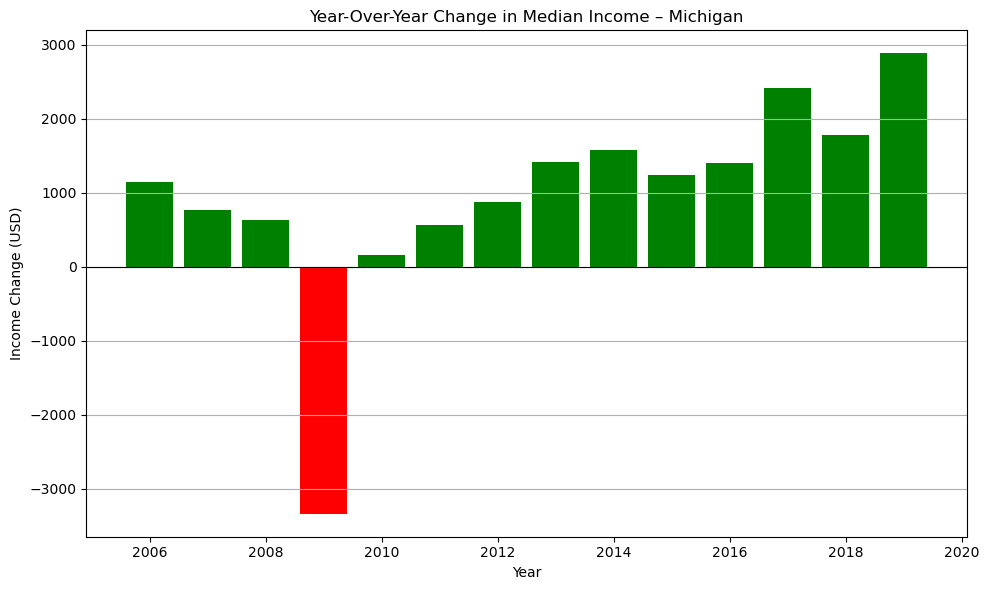

In [117]:
plt.figure(figsize=(10,6))

colors = df['income_change'].apply(lambda x: 'red' if x < 0 else 'green')

plt.bar(df['year'], df['income_change'], color=colors)
plt.axhline(0, color='black', linewidth=0.8)

plt.title("Year-Over-Year Change in Median Income – Michigan")
plt.xlabel("Year")
plt.ylabel("Income Change (USD)")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

Q3: Michigan’s per-person income has steadily increased, showing that residents on average 
are earning more each year. The upward trend points to economic improvement and growth 
in wages across the state. Even though Michigan’s population growth has slowed, the consistent income rise suggests 
a stronger economy and higher productivity per person. The steady climb, without sharp 
fluctuations, highlights financial stability over time.